First 5 Rows:
        Date  Open Price  Close Price  High Price  Low Price     Volume
0 2026-01-02     9931.29      9951.14    10046.25    9930.76  604307136
1 2026-01-02     9931.29      9951.14    10046.25    9930.76  604307136
2 2026-01-02     9931.29      9951.14    10046.25    9930.76  604307136
3 2026-01-05     9951.45     10004.57    10022.05    9951.45  708341696
4 2026-01-06     10004.4     10122.73    10158.41   10003.77  701826240
Columns:
Index(['date', 'open_price', 'close_price', 'high_price', 'low_price',
       'volume'],
      dtype='str')
First 5 rows:
        date  open_price  close_price  high_price  low_price     volume
0 2026-01-02     9931.29      9951.14    10046.25    9930.76  604307136
1 2026-01-02     9931.29      9951.14    10046.25    9930.76  604307136
2 2026-01-02     9931.29      9951.14    10046.25    9930.76  604307136
3 2026-01-05     9951.45     10004.57    10022.05    9951.45  708341696
4 2026-01-06     10004.4     10122.73    10158.41   10003.77  7

/var/folders/fj/21d1_p455_57j8v1wd1q0fl00000gn/T/ipykernel_6559/3042721859.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


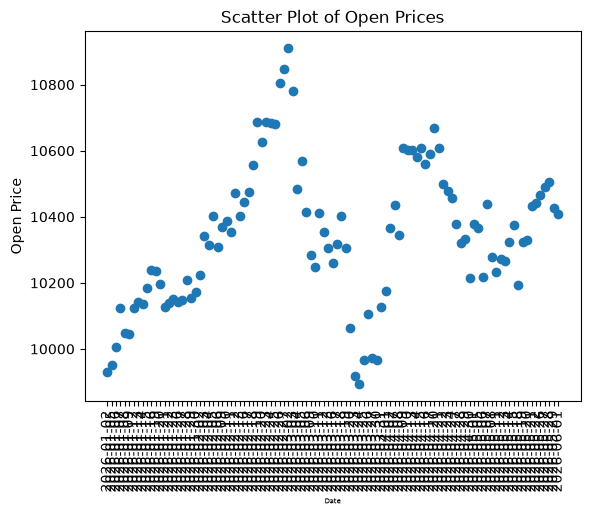

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ftse_100_data = pd.read_csv("prices.csv", parse_dates=["Date"]).convert_dtypes()

print("First 5 Rows:")
print(ftse_100_data.head())

new_column_names = {
    "Date": "date",
    "Open Price": "open_price",
    "Close Price": "close_price",
    "High Price": "high_price",
    "Low Price": "low_price",
    "Volume": "volume",
}

data = ftse_100_data.rename(columns=new_column_names)

print("Columns:")
print(data.columns)

print("First 5 rows:")
print(data.head())

print("Check for missing data:")
print(data.info())

print("Print location of missing daat:")
print(data.loc[data.isna().any(axis="columns")])

print("Adding missing data...")
data = data.rename(columns=new_column_names).combine_first(pd.DataFrame({"low_price": {3: 710032.92}}))

print("First 5 corrected rows:")
print(data.head())

# Remove duplicates
data.loc[data.duplicated(keep=False)]

data = data.drop_duplicates()

data.to_csv("prices-cleaned.csv", index=False)

# Create chart
data = pd.read_csv("prices-cleaned.csv").convert_dtypes()

fig, ax = plt.subplots()
ax.scatter(data["date"], data["open_price"])
ax.set_title("Scatter Plot of Open Prices")
ax.set_xlabel("Date", fontsize = 5)
ax.set_ylabel("Open Price")
ax.tick_params(axis='x', labelrotation=90)

years = mdates.WeekdayLocator()  
ax.xaxis.set_major_locator(years) #Every year

fig.show()